In [1]:
# ══════════════════════════════════════════════
# CELL 1 — Libraries import karo
# ══════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
# ══════════════════════════════════════════════
# CELL 2 — Data load karo aur explore karo
# ══════════════════════════════════════════════
df = pd.read_csv(r'C:\Users\HP\Downloads\cs_training.csv\cs-training.csv')

print("Shape:", df.shape)               # (150000, 12)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

# Yahan aapko dikhe ga:
# - 'Unnamed: 0' — useless index column, hata denge
# - 'SeriousDlqin2yrs' — yeh hamara TARGET (0=safe, 1=defaulter)
# - MonthlyIncome aur NumberOfDependents mein missing values hain

Shape: (150000, 12)

Columns:
 ['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

First 5 rows:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# ══════════════════════════════════════════════
# CELL 3 — Missing values check karo
# ══════════════════════════════════════════════
print("Missing Values Count:")
print(df.isnull().sum())

print("\nMissing Values Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

# MonthlyIncome mein ~20% missing hoga
# NumberOfDependents mein ~2.6% missing hoga

Missing Values Count:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Missing Values Percentage:
Unnamed: 0                               0.00
SeriousDlqin2yrs                         0.00
RevolvingUtilizationOfUnsecuredLines     0.00
age                                      0.00
NumberOfTime30-59DaysPastDueNotWorse     0.00
DebtRatio                                0.00
MonthlyIncome                           19.82
NumberOfOpenCreditLinesAndLoans          0.00
NumberOfTimes90Da

In [5]:
# ══════════════════════════════════════════════
# CELL 4 — Target variable distribution dekho
# ══════════════════════════════════════════════
print("Target Distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nPercentage:")
print((df['SeriousDlqin2yrs'].value_counts() / len(df) * 100).round(2))

# Result aayega:
# 0 (Safe)     = ~93.3%  → 139,974 log
# 1 (Defaulter) = ~6.7%  → 10,026 log
# PROBLEM: Yeh bahut imbalanced hai! Model sirf 0 predict karega
# SOLUTION: SMOTE use karenge baad mein

Target Distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Percentage:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: count, dtype: float64


In [6]:
# ══════════════════════════════════════════════
# CELL 5 — Data cleaning
# ══════════════════════════════════════════════

# Step 1: Unnamed column hata do (yeh sirf row number hai)
df = df.drop('Unnamed: 0', axis=1)
print("After dropping Unnamed:", df.shape)

# Step 2: Missing values fill karo
# Median use karte hain kyunki income mein outliers hote hain
# Mean outliers se affect hota hai, median nahi
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("\nMissing values after fix:")
print(df.isnull().sum())
# Ab koi missing value nahi hogi

After dropping Unnamed: (150000, 11)

Missing values after fix:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [7]:
# ══════════════════════════════════════════════
# CELL 6 — Outliers handle karo (Clipping)
# ══════════════════════════════════════════════

# Kuch values bahut extreme hain — e.g., DebtRatio = 9999
# In values ko reasonable range mein clip karo

print("Before clipping:")
print("DebtRatio max:", df['DebtRatio'].max())
print("Utilization max:", df['RevolvingUtilizationOfUnsecuredLines'].max())
print("Income max:", df['MonthlyIncome'].max())

# DebtRatio: 0 to 1 (100% debt max)
df['DebtRatio'] = df['DebtRatio'].clip(0, 1)

# RevolvingUtilization: 0 to 1 (100% credit used max)
df['RevolvingUtilizationOfUnsecuredLines'] = \
    df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# MonthlyIncome: 0 to 50,000 (realistic max)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(0, 50000)

print("\nAfter clipping:")
print("DebtRatio max:", df['DebtRatio'].max())     # 1.0
print("Utilization max:", df['RevolvingUtilizationOfUnsecuredLines'].max())  # 1.0
print("Income max:", df['MonthlyIncome'].max())     # 50000

Before clipping:
DebtRatio max: 329664.0
Utilization max: 50708.0
Income max: 3008750.0

After clipping:
DebtRatio max: 1.0
Utilization max: 1.0
Income max: 50000.0


In [8]:
# ══════════════════════════════════════════════
# CELL 7 — Features aur Target separate karo
# ══════════════════════════════════════════════

# X = input features (jo model ko dikhayenge)
# y = target (jo model predict karega)
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print("Features shape:", X.shape)   # (150000, 10)
print("Target shape:", y.shape)     # (150000,)
print("\nFeature names:", X.columns.tolist())
print("\nTarget distribution:\n", y.value_counts())

Features shape: (150000, 10)
Target shape: (150000,)

Feature names: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Target distribution:
 SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


In [9]:
# ══════════════════════════════════════════════
# CELL 8 — Train-Test Split
# ══════════════════════════════════════════════

# 80% training, 20% testing
# stratify=y ensures same class ratio in both splits
# random_state=42 ensures same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)  # (120000, 10)
print("Test size:", X_test.shape)    # (30000, 10)
print("\nTrain target distribution:\n", y_train.value_counts())
print("\nTest target distribution:\n", y_test.value_counts())

Train size: (120000, 10)
Test size: (30000, 10)

Train target distribution:
 SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

Test target distribution:
 SeriousDlqin2yrs
0    27995
1     2005
Name: count, dtype: int64


In [10]:
# ══════════════════════════════════════════════
# CELL 9 — SMOTE (Class Imbalance Fix)
# ══════════════════════════════════════════════

# PROBLEM: 93% safe, 7% defaulter
# Model "cheat" karega — sab ko safe bol dega, 93% accuracy milegi
# But yeh useless hai — defaulters pakad nahi payega

# SOLUTION: SMOTE = Synthetic Minority Over-sampling Technique
# Yeh FAKE defaulter records banata hai jo real jaise hote hain
# Result: 50-50 balanced dataset

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())
# Ab dono classes equal hongi! ~111,979 each

Before SMOTE:
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

After SMOTE:
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


In [11]:
# ══════════════════════════════════════════════
# CELL 10 — Feature Scaling (StandardScaler)
# ══════════════════════════════════════════════

# Problem: age=35, income=5000 — ye values ke scales alag hain
# Model income ko zyada important samjhega sirf kyunki number bada hai
# Solution: Sab features ko same scale pe laao (mean=0, std=1)

# IMPORTANT RULE:
# fit_transform() sirf TRAIN data pe — model train data se scale seekhta hai
# transform() TEST data pe — same scale apply karo (lekin test data na dekhe)
# Agar test pe fit karo to "data leakage" hoga — model "future" dekh lega

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)  # Seekho + transform karo
X_test_scaled = scaler.transform(X_test)              # Sirf transform karo

print("Scaling done! ✅")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Scaling done! ✅
Train shape: (223958, 10)
Test shape: (30000, 10)


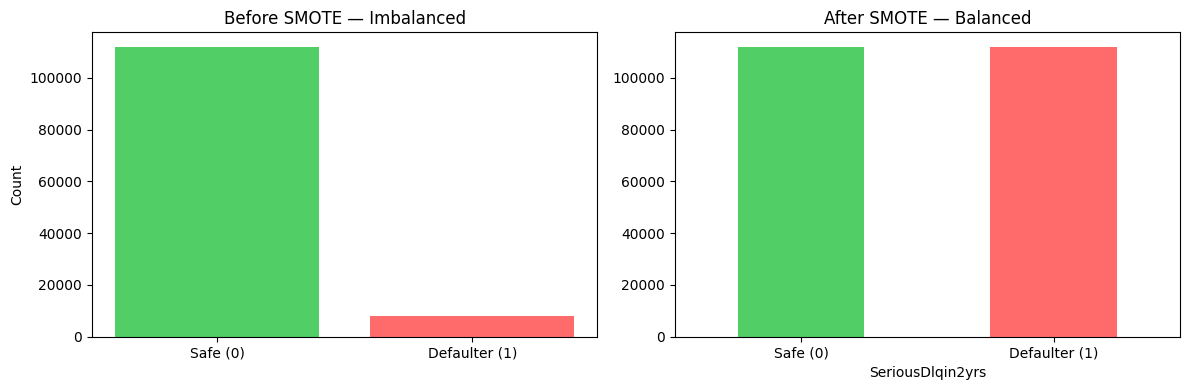

In [12]:
# ══════════════════════════════════════════════
# CELL 11 — Visualization (Optional but useful)
# ══════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
axes[0].bar(['Safe (0)', 'Defaulter (1)'],
            y_train.value_counts().values,
            color=['#51CF66', '#FF6B6B'])
axes[0].set_title('Before SMOTE — Imbalanced')
axes[0].set_ylabel('Count')

# After SMOTE
pd.Series(y_train_smote).value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#51CF66', '#FF6B6B']
)
axes[1].set_title('After SMOTE — Balanced')
axes[1].set_xticklabels(['Safe (0)', 'Defaulter (1)'], rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# ══════════════════════════════════════════════
# CELL 12 — Sab kuch save karo model/ folder mein
# ══════════════════════════════════════════════

os.makedirs('../model', exist_ok=True)

# Scaler save karo (API mein bhi yahi use hoga)
joblib.dump(scaler, '../model/scaler.pkl')

# Processed data save karo (model_training notebook use karega)
np.save('../model/X_train_scaled.npy', X_train_scaled)
np.save('../model/X_test_scaled.npy', X_test_scaled)
np.save('../model/y_train_smote.npy', y_train_smote)
np.save('../model/y_test.npy', y_test)

print("✅ Sab kuch save ho gaya!")
print("Scaler: ../model/scaler.pkl")
print("Train data: ../model/X_train_scaled.npy")
print("Test data: ../model/X_test_scaled.npy")

✅ Sab kuch save ho gaya!
Scaler: ../model/scaler.pkl
Train data: ../model/X_train_scaled.npy
Test data: ../model/X_test_scaled.npy
